First 5 rows of the dataset:
  customer_id  total_orders  average_order_value  average_delivery_distance_km
0        C001            52               784.24                          7.77
1        C002            12               270.79                          2.69
2        C003            37               722.89                          7.80
3        C004             5               236.49                          2.63
4        C005             9               205.59                          3.95

Features used for clustering:
   total_orders  average_order_value  average_delivery_distance_km
0            52               784.24                          7.77
1            12               270.79                          2.69
2            37               722.89                          7.80
3             5               236.49                          2.63
4             9               205.59                          3.95

Scaled feature data:
[[ 1.86769837  1.466381    1.13963974]
 [-

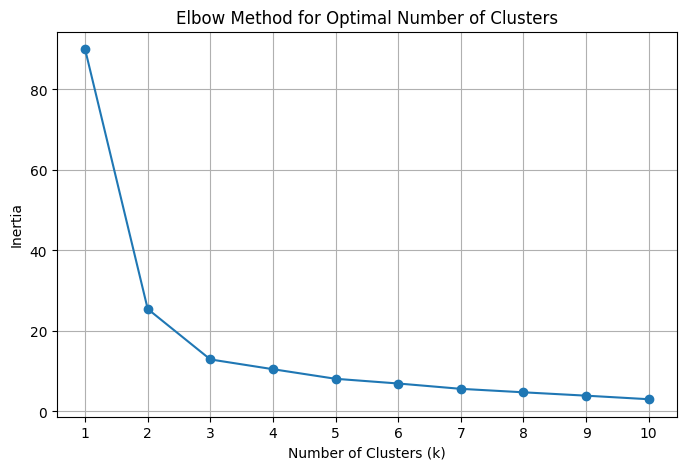


Number of customers in each cluster:
cluster
0    10
1    10
2    10
Name: count, dtype: int64

Cluster Centroids:
         total_orders  average_order_value  average_delivery_distance_km
cluster                                                                 
0                21.8               425.81                          4.96
1                41.6               733.21                          7.84
2                 7.1               223.91                          3.09


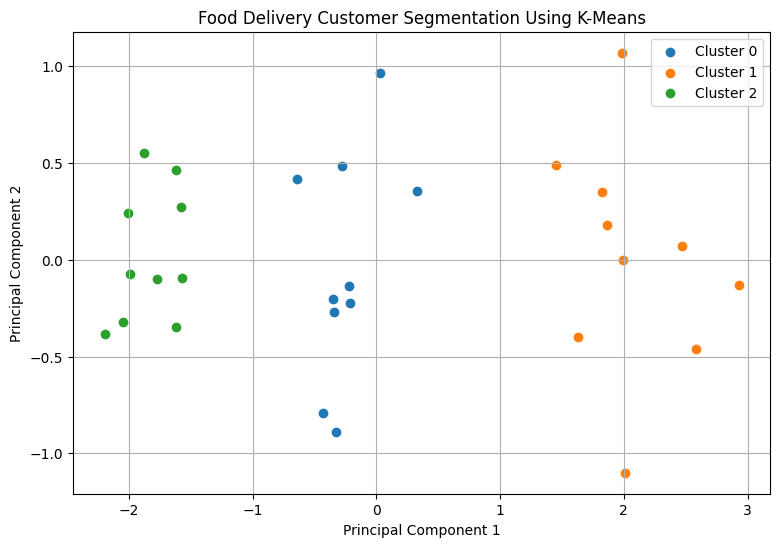


Customer data with cluster assignments:
  customer_id  total_orders  average_order_value  \
0        C001            52               784.24   
1        C002            12               270.79   
2        C003            37               722.89   
3        C004             5               236.49   
4        C005             9               205.59   
5        C006             5               135.55   
6        C007             5               309.23   
7        C008            25               412.92   
8        C009             8               213.35   
9        C010            51               767.21   

   average_delivery_distance_km  cluster  
0                          7.77        1  
1                          2.69        2  
2                          7.80        1  
3                          2.63        2  
4                          3.95        2  
5                          4.13        2  
6                          2.72        2  
7                          4.74        0  

In [4]:
# ============================================================
# FOOD DELIVERY CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# ============================================================
# 1. LOAD THE DATASET
# ============================================================

# Load the customer dataset
df = pd.read_csv("/content/sample_data/food_delivery_customers.csv")

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())


# ============================================================
# 2. SELECT FEATURES FOR CLUSTERING
# ============================================================

# Select only customer behaviour features
# customer_id is NOT included because it is only an identifier
features = [
    "total_orders",
    "average_order_value",
    "average_delivery_distance_km"
]

X = df[features]

print("\nFeatures used for clustering:")
print(X.head())


# ============================================================
# 3. STANDARDIZE THE FEATURES
# ============================================================

# StandardScaler converts the features to a similar scale
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled feature data:")
print(X_scaled[:5])


# ============================================================
# 4. ELBOW METHOD
# ============================================================

# Calculate inertia for different numbers of clusters
inertia = []

# Test cluster numbers from 1 to 10
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    # Store the inertia
    inertia.append(kmeans.inertia_)


# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()


# ============================================================
# 5. APPLY K-MEANS CLUSTERING
# ============================================================

# Select the optimal number of clusters
# Change this value based on the elbow point in the graph
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Create cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)


# Add cluster labels to the original dataframe
df["cluster"] = cluster_labels


# ============================================================
# 6. DISPLAY NUMBER OF CUSTOMERS IN EACH CLUSTER
# ============================================================

print("\nNumber of customers in each cluster:")

cluster_counts = df["cluster"].value_counts().sort_index()

print(cluster_counts)


# ============================================================
# 7. FIND CLUSTER CENTROIDS
# ============================================================

# K-Means centroids are currently in standardized/scaled units.
# Convert them back to the original units.
centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

# Convert centroids into a DataFrame
centroid_df = pd.DataFrame(
    centroids_original,
    columns=features
)

# Round values for easier reading
centroid_df = centroid_df.round(2)

# Add cluster number
centroid_df.index.name = "cluster"

print("\nCluster Centroids:")
print(centroid_df)


# ============================================================
# 8. PCA FOR 2D VISUALIZATION
# ============================================================

# Reduce the 3 features to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame containing PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PCA1", "PCA2"]
)

# Add cluster labels
pca_df["cluster"] = cluster_labels


# ============================================================
# 9. VISUALIZE THE CUSTOMER CLUSTERS
# ============================================================

plt.figure(figsize=(9, 6))

# Plot each cluster separately
for cluster in range(optimal_k):

    cluster_data = pca_df[
        pca_df["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}"
    )


# Add chart labels
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Food Delivery Customer Segmentation Using K-Means")

# Show legend
plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 10. FINAL CUSTOMER DATA
# ============================================================

print("\nCustomer data with cluster assignments:")
print(df.head(10))

First 5 rows of the dataset:
  customer_id  total_orders  average_order_value  average_delivery_distance_km
0        C001            52               784.24                          7.77
1        C002            12               270.79                          2.69
2        C003            37               722.89                          7.80
3        C004             5               236.49                          2.63
4        C005             9               205.59                          3.95

Features used for clustering:
   total_orders  average_order_value  average_delivery_distance_km
0            52               784.24                          7.77
1            12               270.79                          2.69
2            37               722.89                          7.80
3             5               236.49                          2.63
4             9               205.59                          3.95

Scaled feature data:
[[ 1.86769837  1.466381    1.13963974]
 [-

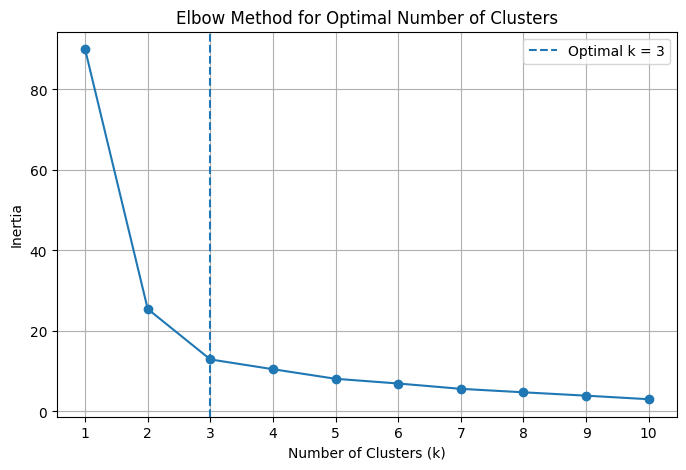


Number of customers in each cluster:
cluster
0    10
1    10
2    10
Name: count, dtype: int64

Cluster Centroids:
         total_orders  average_order_value  average_delivery_distance_km
cluster                                                                 
0                21.8               425.81                          4.96
1                41.6               733.21                          7.84
2                 7.1               223.91                          3.09


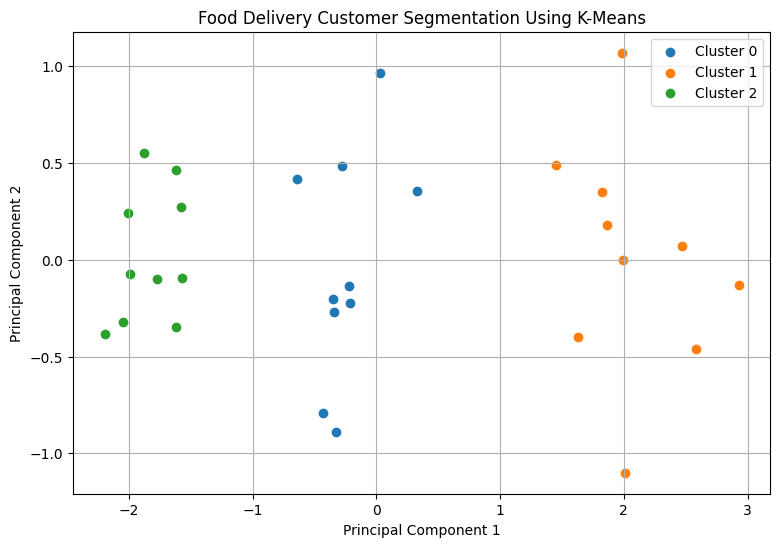


Customer data with cluster assignments:
  customer_id  total_orders  average_order_value  \
0        C001            52               784.24   
1        C002            12               270.79   
2        C003            37               722.89   
3        C004             5               236.49   
4        C005             9               205.59   
5        C006             5               135.55   
6        C007             5               309.23   
7        C008            25               412.92   
8        C009             8               213.35   
9        C010            51               767.21   

   average_delivery_distance_km  cluster  
0                          7.77        1  
1                          2.69        2  
2                          7.80        1  
3                          2.63        2  
4                          3.95        2  
5                          4.13        2  
6                          2.72        2  
7                          4.74        0  

In [5]:
### correction
# -- this code uses self made k-cluster but in k-mean we can't decide directly how many we make
# cluster so we do wcss or elbow method to define it
# ============================================================
# FOOD DELIVERY CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# ============================================================
# 1. LOAD THE DATASET
# ============================================================

# Load the customer dataset
df = pd.read_csv("/content/sample_data/food_delivery_customers.csv")

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())


# ============================================================
# 2. SELECT FEATURES FOR CLUSTERING
# ============================================================

# Select only customer behaviour features
# customer_id is excluded because it is only an identifier
features = [
    "total_orders",
    "average_order_value",
    "average_delivery_distance_km"
]

X = df[features]

print("\nFeatures used for clustering:")
print(X.head())


# ============================================================
# 3. STANDARDIZE THE FEATURES
# ============================================================

# Standardize the three numerical features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled feature data:")
print(X_scaled[:5])


# ============================================================
# 4. ELBOW METHOD
# ============================================================

# Store the inertia values
inertia = []

# Test different numbers of clusters
k_values = range(1, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    # Store inertia
    inertia.append(kmeans.inertia_)


# ============================================================
# 5. AUTOMATICALLY FIND THE ELBOW POINT
# ============================================================

# Convert k values and inertia to NumPy arrays
k_array = np.array(list(k_values))
inertia_array = np.array(inertia)

# First point of the elbow curve
x1 = k_array[0]
y1 = inertia_array[0]

# Last point of the elbow curve
x2 = k_array[-1]
y2 = inertia_array[-1]

# Calculate the distance of every point from
# the straight line between the first and last points
distances = np.abs(
    (y2 - y1) * k_array
    - (x2 - x1) * inertia_array
    + x2 * y1
    - y2 * x1
) / np.sqrt(
    (y2 - y1) ** 2
    + (x2 - x1) ** 2
)

# The point with the maximum distance is the elbow
optimal_k = k_array[np.argmax(distances)]

print("\nOptimal number of clusters selected using Elbow Method:")
print(optimal_k)


# ============================================================
# 6. PLOT THE ELBOW CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_array,
    inertia_array,
    marker="o"
)

# Mark the automatically selected elbow
plt.axvline(
    x=optimal_k,
    linestyle="--",
    label=f"Optimal k = {optimal_k}"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(k_array)
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 7. APPLY K-MEANS USING THE ELBOW VALUE
# ============================================================

# K-Means automatically uses the optimal k
# found by the Elbow Method above
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Create cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df["cluster"] = cluster_labels


# ============================================================
# 8. DISPLAY NUMBER OF CUSTOMERS IN EACH CLUSTER
# ============================================================

print("\nNumber of customers in each cluster:")

cluster_counts = df["cluster"].value_counts().sort_index()

print(cluster_counts)


# ============================================================
# 9. FIND CLUSTER CENTROIDS
# ============================================================

# K-Means centroids are in standardized units.
# Convert them back to the original units.
centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

# Convert centroids into a DataFrame
centroid_df = pd.DataFrame(
    centroids_original,
    columns=features
)

# Round centroid values to 2 decimal places
centroid_df = centroid_df.round(2)

# Add cluster number
centroid_df.index.name = "cluster"

print("\nCluster Centroids:")
print(centroid_df)


# ============================================================
# 10. PCA FOR 2D VISUALIZATION
# ============================================================

# Reduce the 3 standardized features to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PCA1", "PCA2"]
)

# Add cluster labels
pca_df["cluster"] = cluster_labels


# ============================================================
# 11. VISUALIZE THE CUSTOMER CLUSTERS
# ============================================================

plt.figure(figsize=(9, 6))

# Plot each cluster separately
for cluster in range(optimal_k):

    cluster_data = pca_df[
        pca_df["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}"
    )


# Add axis labels and title
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Food Delivery Customer Segmentation Using K-Means"
)

# Show legend
plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 12. FINAL CUSTOMER DATA
# ============================================================

print("\nCustomer data with cluster assignments:")
print(df.head(10))

### prompt
Create a Python machine learning project that performs **K-Means Clustering** on a food delivery customer dataset.

Requirements:

1. Use a dataset with at least **3 numeric features**:
   - `total_orders`
   - `average_order_value`
   - `average_delivery_distance_km`
2. **Exclude** **`customer_id`** **from the clustering features** because it is an identifier, not a customer-behaviour feature.
3. Apply **StandardScaler** to scale the numeric features before clustering.
4. Use the **Elbow Method** to find the optimal number of clusters and plot the **inertia vs. number of clusters** curve.
5. Apply **K-Means Clustering** using the selected optimal number of clusters.
6. Print:
   - Each cluster's **centroid values**
   - Number of customers assigned to each cluster
7. Use **PCA** to reduce the 3 features to **2 dimensions** for visualization.
8. Create a 2D scatter plot of the PCA-reduced data:
   - Show each cluster in a **different colour**
   - Include a clear **legend**
   - Add proper axis labels and title

Keep the code **simple, clean, beginner-friendly, and well-commented**. Use Python libraries such as **Pandas, NumPy, Matplotlib, and Scikit-learn**.